### Dynamic lot-sizing

In this section, we formulate the dynamic lot-sizing problem. We define the following additional input data:  
$T$, the set of periods in the planning horizon; $d_t$, the demand in period $t$; $c_x$, the unit production cost; $c_I$, the unit inventory holding cost; $c_s$, the fixed setup cost; and $M$, a sufficiently large constant (or the maximum production capacity per period).

Finally, we define the following decision variables:

$$
y_t =
\begin{cases}
1 & \text{if setup is activated (production takes place) in period } t, \\
0 & \text{otherwise.}
\end{cases}
$$

$x_t$ is the quantity produced in period $t$.

$I_t$ is the inventory at the end of period $t$.

With this notation, the dynamic lot-sizing problem can be formulated as follows:

$$
\begin{aligned}
\text{min} \quad & \sum_{t \in T} \left( c_x x_t + c_I I_t + c_s y_t \right) \\
\text{subject to} \quad & I_{t-1} + x_t = d_t + I_t \quad \forall t \in T \\
& x_t - M y_t \leq 0 \quad \forall t \in T \\
& y_t \in \{0,1\} \quad \forall t \in T \\
& x_t \geq 0 \quad \forall t \in T \\
& I_t \geq 0 \quad \forall t \in T
\end{aligned}
$$

In [1]:
%pip install gurobipy
from gurobipy import Model, GRB, quicksum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 50.1 MB/s eta 0:00:00


In [2]:
# Data

# Set and notation
T = [*range(1, 10)]

# Parameters
Demand = [0, 500, 300, 200, 700, 350, 400, 450, 700, 200]
# Inventory_cost = 2
Inventory_cost = 0.2
Setup_cost = 50
Production_cost = 10
Initial_inventory = 0
# Big_M = 150
# Big_M = 5000
Big_M = 10000

In [3]:
# Define model
m = Model("Lot_sizing")

# Decision variables
Inventory = m.addVars(T, vtype=GRB.CONTINUOUS, name="Inventory")
Production = m.addVars(T, vtype=GRB.CONTINUOUS, name="Production")
Setup = m.addVars(T, vtype=GRB.BINARY, name="Setup")

# Objective function

# Cost components
Total_inventory_cost = quicksum(Inventory_cost * Inventory[t] for t in T)
Total_production_cost = quicksum(Production_cost * Production[t] for t in T)
Total_setup_cost = quicksum(Setup_cost * Setup[t] for t in T)

# Total cost
Total_cost = Total_inventory_cost + Total_production_cost + Total_setup_cost

# Define objective
m.setObjective(Total_cost)

# Inventory balance constraints
for t in T:
    if t == 1:
        m.addConstr(Initial_inventory + Production[t] == Demand[t] + Inventory[t])

for t in T:
    if t >= 2:
        m.addConstr(Inventory[t - 1] + Production[t] == Demand[t] + Inventory[t])

# Alternative compact version:
# m.addConstrs((Initial_inventory + Production[t] == Demand[t] + Inventory[t]) for t in T if t == 1)
# m.addConstrs((Inventory[t - 1] + Production[t] == Demand[t] + Inventory[t]) for t in T if t >= 2)

# Setup constraints
for t in T:
    m.addConstr(Production[t] <= Big_M * Setup[t])

# Alternative compact version:
# m.addConstrs((Production[t] <= Big_M * Setup[t]) for t in T)

# Export model to LP file
m.write("Lot-sizing.lp")

# Optimize
m.optimize()

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 18 rows, 27 columns and 44 nonzeros (Min)
Model fingerprint: 0x72191996
Model has 27 linear objective coefficients
Variable types: 18 continuous, 9 integer (9 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+04]
  Objective range  [2e-01, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+02, 7e+02]

Presolve removed 3 rows and 4 columns
Presolve time: 0.00s
Presolved: 15 rows, 23 columns, 37 nonzeros
Variable types: 15 continuous, 8 integer (8 binary)
Found heuristic solution: objective 38450.000000

Root relaxation: objective 3.815089e+04, 19 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     W

In [5]:
# Report results
print('\nTotal cost: %g' % m.ObjVal)
print('Solution:')
for t in T:
    print("")
    print("Period:", t)
    if Setup[t].X > 0.99:
        print('Setup is activated')
    else:
        print('Setup is not activated')
    if Production[t].X > 0:
        print('Produce %g units' % Production[t].X)
    if Inventory[t].X > 0:
        print('Ending inventory: %g units' % Inventory[t].X)
print("")


Total cost: 38430
Solution:

Period: 1
Setup is activated
Produce 500 units

Period: 2
Setup is activated
Produce 500 units
Ending inventory: 200 units

Period: 3
Setup is not activated

Period: 4
Setup is activated
Produce 700 units

Period: 5
Setup is activated
Produce 350 units

Period: 6
Setup is activated
Produce 400 units

Period: 7
Setup is activated
Produce 450 units

Period: 8
Setup is activated
Produce 900 units
Ending inventory: 200 units

Period: 9
Setup is not activated



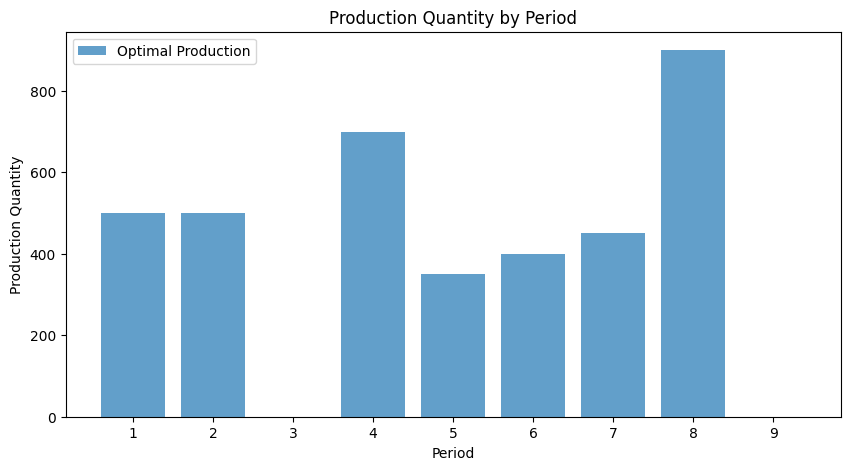

In [6]:
import matplotlib.pyplot as plt

# Model results
optimal_production = [Production[t].X for t in T]

# Bar chart of production quantity by period
plt.figure(figsize=(10, 5))
plt.bar(T, optimal_production, alpha=0.7, label='Optimal Production')
plt.xlabel('Period')
plt.ylabel('Production Quantity')
plt.title('Production Quantity by Period')
plt.xticks(T)
plt.legend()
plt.show()